AMAZON KINDLE STORE Sentiment analysis

Best Practices
1. Preprocession and cleaning
2. Train Test Split
3. BOW,TFIDF,WORD2vec
4. Train ML algorithm

In [37]:
import pandas as pd
data=pd.read_csv('all_kindle_review.csv',encoding='utf-8')
data

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000
...,...,...,...,...,...,...,...,...,...,...,...
11995,11995,2183,B001DUGORO,"[0, 0]",4,Valentine cupid is a vampire- Jena and Ian ano...,"02 28, 2014",A1OKS5Q1HD8WQC,lisa jon jung,jena,1393545600
11996,11996,6272,B002JCSFSQ,"[2, 2]",5,I have read all seven books in this series. Ap...,"05 16, 2011",AQRSPXLNEQAMA,TerryLP,Peacekeepers Series,1305504000
11997,11997,12483,B0035N1V7K,"[0, 1]",3,This book really just wasn't my cuppa. The si...,"07 26, 2013",A2T5QLT5VXOJAK,hwilson,a little creepy,1374796800
11998,11998,3640,B001W1XT40,"[1, 2]",1,"tried to use it to charge my kindle, it didn't...","09 17, 2013",A28MHD2DDY6DXB,"Allison A. Slater ""Gryphon50""",didn't work,1379376000


In [38]:
df=data[['reviewText','rating']]

In [39]:
df.shape

(12000, 2)

In [40]:
##Missing values
df.isnull().sum()

reviewText    0
rating        0
dtype: int64

In [41]:
df['rating'].unique()

array([3, 5, 4, 2, 1])

In [42]:
df['rating'].value_counts() #balanced data

rating
5    3000
4    3000
3    2000
2    2000
1    2000
Name: count, dtype: int64

In [43]:
#preprocessing and cleaning the data

In [44]:
#pos rev is 1 and neg is 0
df['rating']=df['rating'].apply(lambda x: 0 if x < 3 else 1)
df['rating'].unique()

array([1, 0])

In [45]:
df['rating'].value_counts() #Still we will count as balanced data

rating
1    8000
0    4000
Name: count, dtype: int64

In [46]:
#Lower all the cases
df['reviewText']=df['reviewText'].str.lower()
df['reviewText'].head()

0    jace rankin may be short, but he's nothing to ...
1    great short read.  i didn't want to put it dow...
2    i'll start by saying this is the first of four...
3    aggie is angela lansbury who carries pocketboo...
4    i did not expect this type of book to be in li...
Name: reviewText, dtype: str

In [47]:
df

,reviewText,rating
0,"jace rankin may be short, but he's nothing to ...",1
1,great short read. i didn't want to put it dow...,1
2,i'll start by saying this is the first of four...,1
3,aggie is angela lansbury who carries pocketboo...,1
4,i did not expect this type of book to be in li...,1
...,...,...
11995,valentine cupid is a vampire- jena and ian ano...,1
11996,i have read all seven books in this series. ap...,1
11997,this book really just wasn't my cuppa. the si...,1
11998,"tried to use it to charge my kindle, it didn't...",0


In [48]:
#!pip install nltk
#nltk.download('stopwords')
#nltk.download('punkt')
#nltk.download('wordnet')

In [49]:
import re
import html
from nltk.corpus import stopwords

stopwords = set(stopwords.words('english'))

def clean_review(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = html.unescape(text)
    text = re.sub(r'http\S+|www\.\S+|ftp\S+', " ", text)
    text = re.sub(r'<.*?>', " ", text)
    text = re.sub(r'[^a-z\s]', " ", text)
    text = re.sub(r'\s+', " ", text).strip()
    return " ".join(word for word in text.split() if word not in stopwords)

df['reviewText'] = df['reviewText'].apply(clean_review)

In [50]:
df.head()

,reviewText,rating
0,jace rankin may short nothing mess man hauled ...,1
1,great short read want put read one sitting sex...,1
2,start saying first four books expecting conclu...,1
3,aggie angela lansbury carries pocketbooks inst...,1
4,expect type book library pleased find price right,1


In [51]:
#Lemmatizer
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
def lemmatize_words(text):
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])
df['reviewText'] = df['reviewText'].apply(lemmatize_words)

In [52]:
df.head()

,reviewText,rating
0,jace rankin may short nothing mess man hauled ...,1
1,great short read want put read one sitting sex...,1
2,start saying first four book expecting conclud...,1
3,aggie angela lansbury carry pocketbook instead...,1
4,expect type book library pleased find price right,1


Train test Split

In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['reviewText'], df['rating'], test_size=0.2)


In [54]:
from sklearn.feature_extraction.text import CountVectorizer
bow=CountVectorizer()
X_train_bow=bow.fit_transform(X_train).toarray()
X_test_bow=bow.transform(X_test).toarray() #no data leakage if only transform is used in test data


In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer()
X_train_tfidf=tfidf.fit_transform(X_train).toarray()
X_test_tfidf=tfidf.transform(X_test).toarray() #no data leakage if only transform is used in test data

In [56]:
X_train_bow.shape, X_test_bow.shape, X_train_tfidf.shape, X_test_tfidf.shape

((9600, 23882), (2400, 23882), (9600, 23882), (2400, 23882))

In [57]:
X_train_bow

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(9600, 23882))

In [58]:
from sklearn.naive_bayes import MultinomialNB
mb_model_bow=MultinomialNB().fit(X_train_bow,y_train)
mb_model_tfidf=MultinomialNB().fit(X_train_tfidf,y_train)

In [59]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_bow=mb_model_bow.predict(X_test_bow)
y_pred_tfidf=mb_model_tfidf.predict(X_test_tfidf)

print("Accuracy (Bag of Words):", accuracy_score(y_test, y_pred_bow))
print("Accuracy (TF-IDF):", accuracy_score(y_test, y_pred_tfidf))
#here word2vec is definately better than these 2

Accuracy (Bag of Words): 0.8316666666666667
Accuracy (TF-IDF): 0.7195833333333334


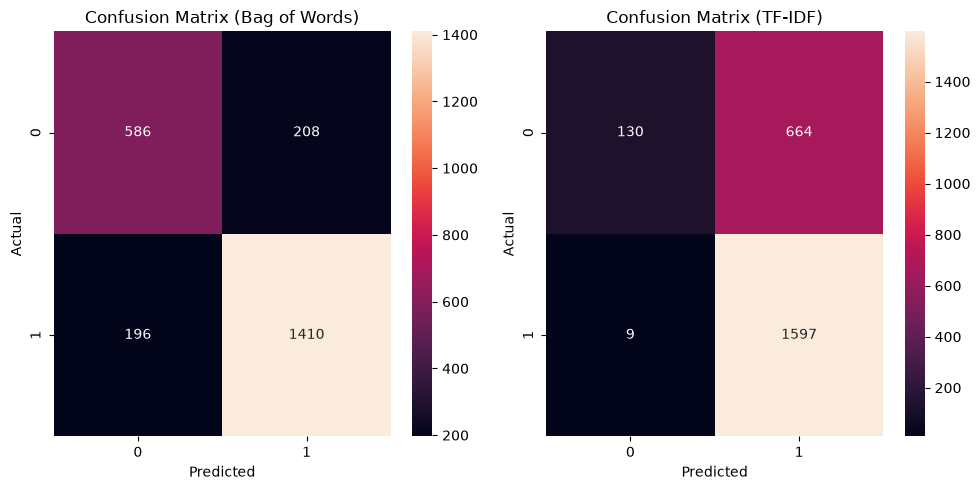

In [60]:
#make a beatuiful confusion matrix
confusion_matrix_bow=confusion_matrix(y_test, y_pred_bow)
confusion_matrix_tfidf=confusion_matrix(y_test, y_pred_tfidf)
#now design a beautiful confusion matrix using seaborn
#!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix_bow, annot=True, fmt='d')
plt.title('Confusion Matrix (Bag of Words)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix_tfidf, annot=True, fmt='d')
plt.title('Confusion Matrix (TF-IDF)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

In [61]:
# word2vec embeddings for each review
#!pip install gensim

from gensim.models import Word2Vec
import numpy as np

sentences = [text.split() for text in X_train]

w2v_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=45,
    seed=42
)

def document_vector(text):
    words = [w for w in text.split() if w in w2v_model.wv]
    if not words:
        return np.zeros(w2v_model.vector_size)
    return np.mean(w2v_model.wv[words], axis=0)

X_train_w2v = np.vstack([document_vector(text) for text in X_train])
X_test_w2v = np.vstack([document_vector(text) for text in X_test])

from sklearn.naive_bayes import GaussianNB
nb_model_w2v = GaussianNB().fit(X_train_w2v, y_train)

y_pred_w2v = nb_model_w2v.predict(X_test_w2v)

print("Accuracy (Word2Vec):", accuracy_score(y_test, y_pred_w2v))
print(classification_report(y_test, y_pred_w2v))

Accuracy (Word2Vec): 0.7654166666666666
              precision    recall  f1-score   support

           0       0.61      0.79      0.69       794
           1       0.88      0.75      0.81      1606

    accuracy                           0.77      2400
   macro avg       0.75      0.77      0.75      2400
weighted avg       0.79      0.77      0.77      2400



In [62]:
#Predicting by using the model on new data or review

In [64]:
def predict_sentiment_bow(text):
    text = clean_review(text)
    text = lemmatize_words(text)
    vec = bow.transform([text]).toarray()
    return mb_model_bow.predict(vec)[0]

def predict_sentiment_tfidf(text):
    text = clean_review(text)
    text = lemmatize_words(text)
    vec = tfidf.transform([text]).toarray()
    return mb_model_tfidf.predict(vec)[0]

def predict_sentiment_w2v(text):
    text = clean_review(text)
    text = lemmatize_words(text)
    vec = document_vector(text).reshape(1, -1)
    return nb_model_w2v.predict(vec)[0]

reviews = [
    input("Enter review 1: "),
    input("Enter review 2: ")
]

for idx, text in enumerate(reviews, start=1):
    bow_label = "positive" if predict_sentiment_bow(text) == 1 else "negative"
    tfidf_label = "positive" if predict_sentiment_tfidf(text) == 1 else "negative"
    w2v_label = "positive" if predict_sentiment_w2v(text) == 1 else "negative"
    print(f"\nReview {idx}: {text}")
    print(f"  BOW      : {bow_label}")
    print(f"  TF-IDF   : {tfidf_label}")
    print(f"  Word2Vec : {w2v_label}")



Review 1: The product was disappointing, slow and full of errors. I regret buying it.
  BOW      : negative
  TF-IDF   : positive
  Word2Vec : negative

Review 2: I love this Kindle book. The story was engaging and the formatting is excellent.
  BOW      : positive
  TF-IDF   : positive
  Word2Vec : positive
